In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","num"
]

In [12]:
df = pd.read_csv(
    "processed.switzerland.data",
    header=None,
    names=columns,
    na_values="?"
)
df = df.apply(pd.to_numeric, errors="coerce")


In [36]:
#print(df.dtypes)  

df.fillna(df.mean(), inplace=True)
print("\nMissing values after handling:")
print(df.isnull().sum())




Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [20]:
X = df.drop("num", axis=1)
y = df["num"]

In [22]:
print(X.head())


         age       sex        cp    trestbps  chol       fbs   restecg  \
0  55.317073  0.918699  3.699187  130.206612   0.0  0.104167  0.360656   
1  32.000000  1.000000  1.000000   95.000000   0.0  0.104167  0.000000   
2  34.000000  1.000000  4.000000  115.000000   0.0  0.104167  0.360656   
3  35.000000  1.000000  4.000000  130.206612   0.0  0.104167  0.000000   
4  36.000000  1.000000  4.000000  110.000000   0.0  0.104167  0.000000   

      thalach     exang   oldpeak     slope   ca      thal  
0  121.557377  0.442623  0.653846  1.801887  1.6  5.788732  
1  127.000000  0.000000  0.700000  1.000000  1.6  5.788732  
2  154.000000  0.000000  0.200000  1.000000  1.6  5.788732  
3  130.000000  1.000000  0.653846  1.801887  1.6  7.000000  
4  125.000000  1.000000  1.000000  2.000000  1.6  6.000000  


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X.head())

         age       sex        cp    trestbps  chol       fbs   restecg  \
0  55.317073  0.918699  3.699187  130.206612   0.0  0.104167  0.360656   
1  32.000000  1.000000  1.000000   95.000000   0.0  0.104167  0.000000   
2  34.000000  1.000000  4.000000  115.000000   0.0  0.104167  0.360656   
3  35.000000  1.000000  4.000000  130.206612   0.0  0.104167  0.000000   
4  36.000000  1.000000  4.000000  110.000000   0.0  0.104167  0.000000   

      thalach     exang   oldpeak     slope   ca      thal  
0  121.557377  0.442623  0.653846  1.801887  1.6  5.788732  
1  127.000000  0.000000  0.700000  1.000000  1.6  5.788732  
2  154.000000  0.000000  0.200000  1.000000  1.6  5.788732  
3  130.000000  1.000000  0.653846  1.801887  1.6  7.000000  
4  125.000000  1.000000  1.000000  2.000000  1.6  6.000000  


In [27]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[1.54589532e-01 1.42699125e-01 1.13499749e-01 1.07023162e-01
 8.73166871e-02 7.98366908e-02 7.52919162e-02 6.31527740e-02
 5.80767574e-02 4.45490936e-02 4.16629697e-02 3.23015436e-02
 2.31179847e-34]


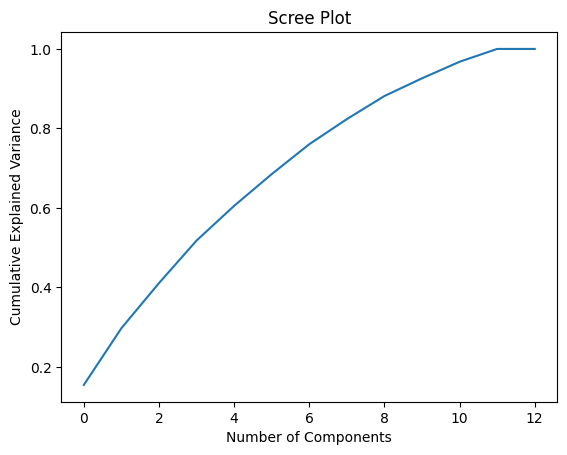

In [28]:
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.show()

In [34]:
pca = PCA(n_components=8)
X_pca_8 = pca.fit_transform(X_scaled)

print("New shape:", X_pca_8.shape)
print("Variance retained:", sum(pca.explained_variance_ratio_))



New shape: (124, 8)
Variance retained: 0.8234096356790963
